$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 4.1

## 理论

设设计集合 $D = \{x_i\}_{i=1}^n$，试验区域为 $X = [0, 1]^p$。考察式 (3.1) 中的积分均方根误差准则：

$$
IRMSE(D; \theta) = \int_{\mathcal{X}}\sqrt{1 - \boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}\boldsymbol{r}(\boldsymbol{x})}d\boldsymbol{x}
$$

式中 $\boldsymbol{r}(\boldsymbol{x}) = \{R(\boldsymbol{x} - \boldsymbol{x}_i)\}_{i=1}^n$，$\boldsymbol{R} = \{R(x_i - x_j)\}_{i,j=1}^n$，$R(\cdot)$ 为相关函数。将试验区域划分为 $n$ 个沃罗诺伊区域：$\mathcal{X} = V_1 \cup \dots \cup V_n$，其中

$$
V_i = \{\boldsymbol{x} \in \mathcal{X}: \|\boldsymbol{x} - \boldsymbol{x}_i\| \le \|\boldsymbol{x} - \boldsymbol{x}_j\|,\quad\forall j \ne i\}
\tag{4.1}
$$

由于当 $i \ne j$ 时 $V_i \cap V_j = \emptyset$，可得：

$$
IRMSE(D; \theta) = \sum_{i=1}^n \int_{V_i}\sqrt{1 - \boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}\boldsymbol{r}(\boldsymbol{x})}d\boldsymbol{x}
$$

新增采样点会使后验方差减小，因此 $1 - \boldsymbol{r}(x)'\boldsymbol{R}^{-1}\boldsymbol{r}(x)$ 的值小于仅采用单个设计点得到的方差（勒普基等人，2010），由此可得：

$$
1 - \boldsymbol{r}(\boldsymbol{x})'\boldsymbol{R}^{-1}\boldsymbol{r}(\boldsymbol{x}) \le 1 - R^2(\boldsymbol{x} - \boldsymbol{x}_i),\quad\forall i
\tag{4.2}
$$

进而有：

$$
IRMSE(D; \theta) \le \sum_{i=1}^n \int_{V_i}\sqrt{1 - R^2(\boldsymbol{x} - \boldsymbol{x}_i)}d\boldsymbol{x}
$$

采用各向同性高斯相关函数

$$
R(\boldsymbol{\Delta}) = \exp\left(-\frac{\|\boldsymbol{\Delta}\|^2}{\theta^2}\right)
\tag{4.3}
$$

则

$$
\begin{align*}
IRMSE(D; \theta) &\le \sum_{i=1}^n \int_{V_i}\sqrt{1 - \exp\left(-\frac{2\|\boldsymbol{x} - \boldsymbol{x}_i\|^2}{\theta^2}\right)}d\boldsymbol{x} \\
&\approx \sum_{i=1}^n \int_{V_i}\sqrt{1 - \left(1 - \frac{2\|\boldsymbol{x} - \boldsymbol{x}_i\|^2}{\theta^2}\right)}d\boldsymbol{x} \\
&= \frac{\sqrt{2}}{\theta}\sum_{i=1}^n \int_{V_i}\|\boldsymbol{x} - \boldsymbol{x}_i\|d\boldsymbol{x}
\end{align*}
$$

通过最小化该上界，可求得最优设计：

$$
\min_{D}\;\sum_{i=1}^n \int_{V_i}\|\boldsymbol{x} - \boldsymbol{x}_i\|d\boldsymbol{x}
\tag{4.4}
$$

式 (4.4) 的优化问题属于量化问题，可借助聚类算法求解。求解步骤如下：首先在区域 $X$ 内生成大量均匀样本 $\{\boldsymbol{X}_i\}_{i=1}^N$，再结合蒙特卡洛近似，原问题可转化为求解：

$$
\min_{D}\;\frac{1}{N}\sum_{j=1}^N\sum_{i=1}^n \delta_{ij}\|\boldsymbol{X}_j - \boldsymbol{x}_i\|
\tag{4.5}
$$

其中若 $\boldsymbol{X}_j \in V_i$，则 $\delta_{ij}=1$，否则 $\delta_{ij}=0$。

同理，式 (3.2) 中的均方积分误差准则可导出 $L_2$ 量化问题：

$$
\min_D\sum_{i=1}^n\int_{V_i}\|\boldsymbol{x}-\boldsymbol{x}_i\|^2 d\boldsymbol{x}
\tag{4.6}
$$

以及对应的蒙特卡洛近似形式：

$$
\min_D\frac{1}{N}\sum_{j=1}^N\sum_{i=1}^n\delta_{ij}\|\boldsymbol{X}_j-\boldsymbol{x}_i\|^2
\tag{4.7}
$$

假设我们需要在试验区域 $X = [0, 1]^2$ 内选取 $n=7$ 个试验点，可借助 R 语言程序包 SFDesign（王、约瑟夫，2025c）求得基于聚类的最优试验设计。由式 (4.4) 构造的试验设计结果如图 4.1 所示。不难发现这些试验点能够很好地布满整个区域，但点位明显向中心过度聚拢，这种布局并不适用于预测类问题。原因在于绝大多数统计模型与机器学习模型擅长插值预测（在 7 个试验点构成的凸包内部开展预测），而外推预测（在凸包外部做预测）的结果往往缺乏可靠性。

## 实践

创建画布宽 10 英寸、高 10 英寸。设 p=2，n=7，种子为 1。导入 mined 包，调用 Lattice() 函数在 p 维 $[0,1]^p$ 空间生成总共 10000 个均匀网格样本点，令其为 X。对 X 做 kmeans 聚类，指定聚为 n 类，取聚类结果的 center 列正是每类的中心点，作为基于聚类的试验设计初始点，令其为 D2。导入 SFDesign 包，调用 clustering.design() 函数构造基于聚类的最优空间填充设计，其中点数为 n，维度为 p，初始点集为 D2，取设计结果的 design 列正是最终的试验设计点集，令其为 D，其中 D 有 2 列，分别对应点的横纵坐标。调用 plot() 函数绘制 D 的散点图，设置 x 轴范围为 c(0,1)，y 轴范围为 c(0,1)，标题为“基于聚类的试验设计”，x 轴标签为 expression(x[1])，y 轴标签为 expression(x[2])，点形状为 16，点颜色为 blue，点大小为 3，标题字体大小为 3，坐标轴标签字体大小为 2，坐标轴刻度字体大小为 2。导入 deldir 包，调用 deldir() 函数对 D 做沃罗诺伊分割，其中将 D 的 2 列分隔开来作为 2 个参数，令其结果为 vor。调用 plot.deldir() 函数叠加 vor 的沃罗诺伊分割图，其中图像为叠加，仅显示分割线，线宽为 3，不显示点。

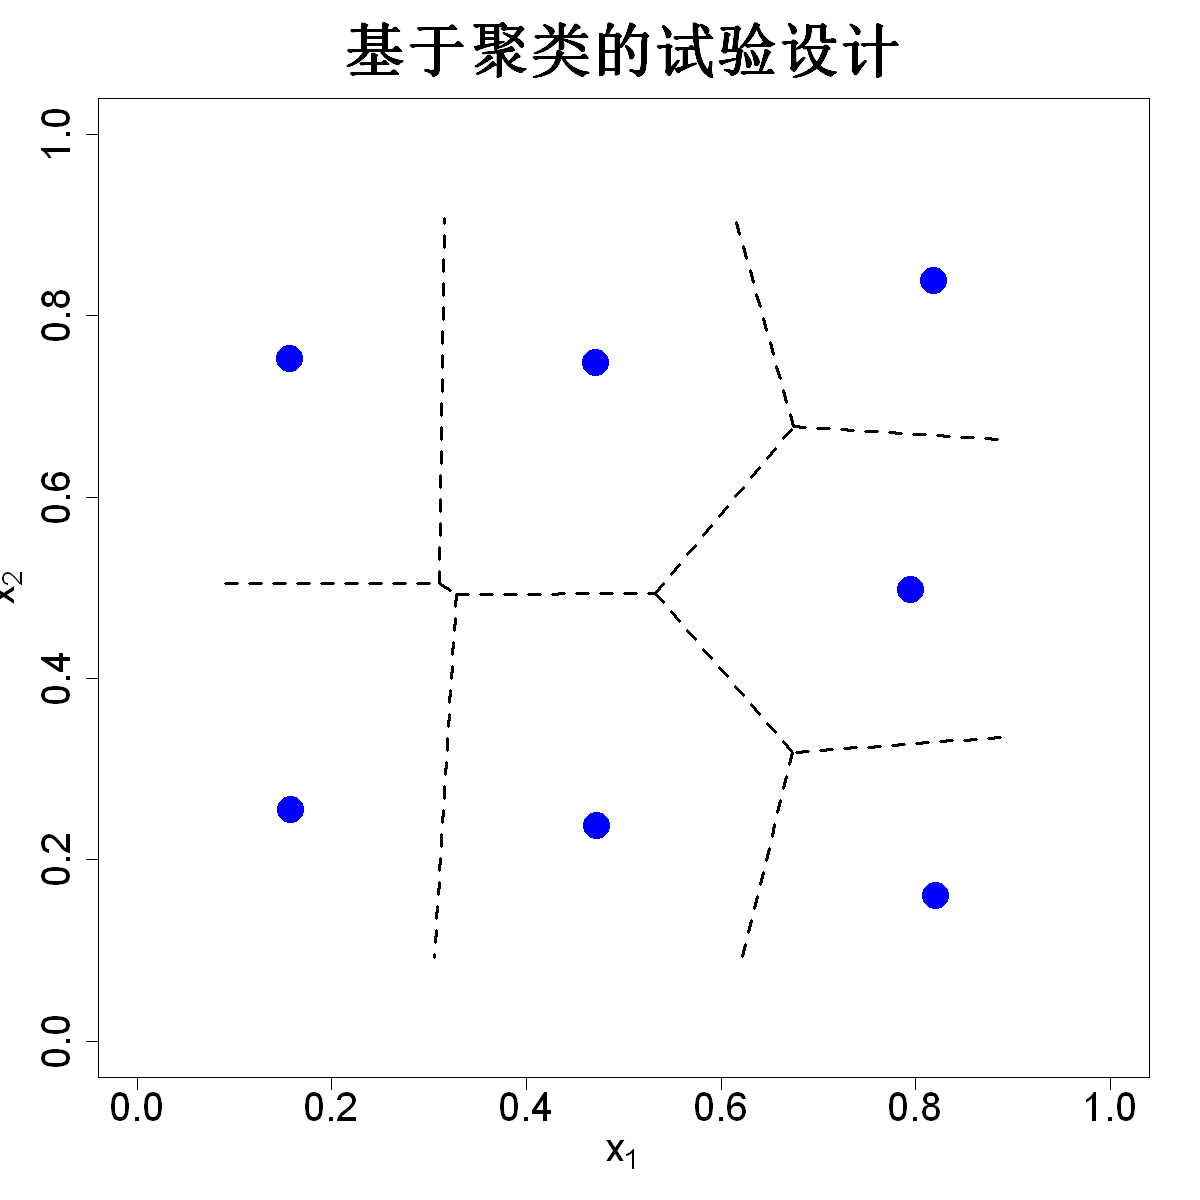

In [2]:
options(repr.plot.width=10,repr.plot.height=10)
p=2;n=7
set.seed(1)
library(mined)
X=Lattice(10000,p)
D2=kmeans(X,centers=n)$centers
library(SFDesign)
D=clustering.design(n,p,D.ini=D2)$design
plot(D,xlim=c(0,1),ylim=c(0,1),main="基于聚类的试验设计",xlab=expression(x[1]),ylab=expression(x[2]),pch=16,col="blue",cex=3,cex.main=3,cex.lab=2,cex.axis=2)
library(deldir)
vor=deldir(D[,1],D[,2])
plot.deldir(vor,add=TRUE,wlines="tess",lwd=3,showpoints=FALSE)

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$